In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm

# homoscedastic

Text(0.5, 0, 'Quasars positions')

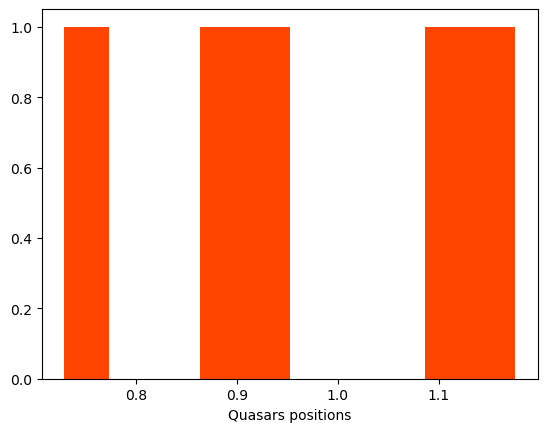

In [2]:
N = 5 #measurements
mu = 1 #true position
sigma = 0.2
positions = np.random.normal(loc=mu, scale=sigma, size=N) #data drawn from that distribution
plt.hist(positions, color="orangered")
plt.xlabel("Quasars positions")

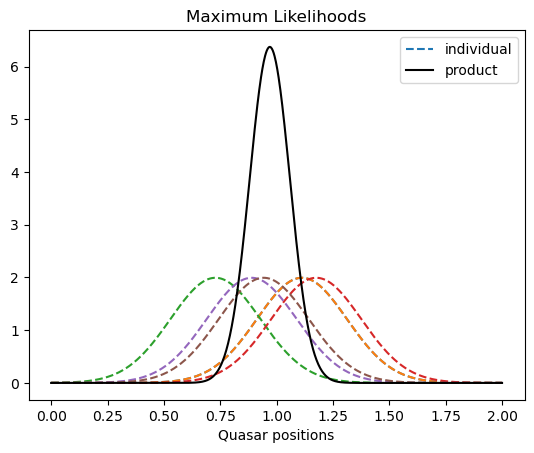

In [3]:
x = np.linspace(mu-5*sigma, mu+5*sigma, 1000)
ML = 1

plt.plot(x, norm(positions[0], sigma).pdf(x), ls="--", label="individual") #plotting this just for the label

#now plotting individual likelihoods, as if each of the observations was an estimate of the true distribution
for point in positions:
    MLi = norm(point, sigma).pdf(x)
    plt.plot(x, MLi, ls="--")
    ML*=MLi #computing Likelihood of the sample

plt.plot(x, ML, "k", label="product")
plt.xlabel("Quasar positions")
plt.title("Maximum Likelihoods")
plt.legend()

Text(0, 0.5, 'ln($L$)')

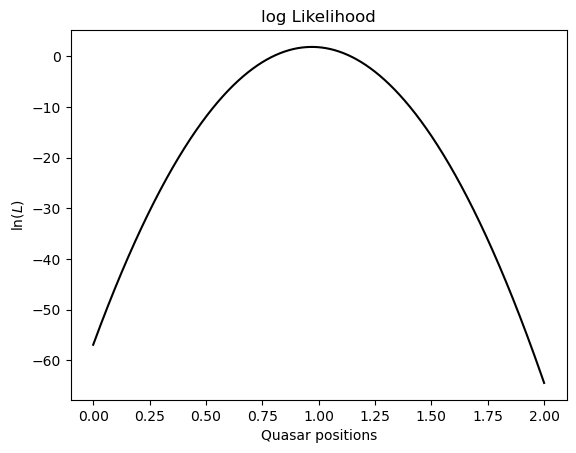

In [4]:
plt.plot(x, np.log(ML), color="k")
plt.title("log Likelihood")
plt.xlabel("Quasar positions")
plt.ylabel("ln($L$)")

max L :  0.968968968968969
mean  :  0.9698693598559018


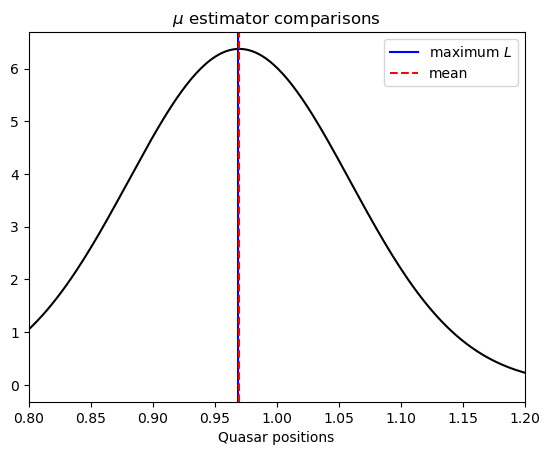

In [5]:
sorted_indices = np.argsort(ML)
index_max = sorted_indices[-1] #the last one is the biggest because they're sorted
max_L_mu = x[index_max] #position where the Likelihood is max

mean = np.mean(positions)

plt.plot(x, ML, "k")
plt.axvline(max_L_mu, color="b", label="maximum $L$")
plt.axvline(mean, color="r", ls="--", label="mean")
plt.xlabel("Quasar positions")
plt.xlim(mu-sigma, mu+sigma)
plt.title("$\\mu$ estimator comparisons")
plt.legend()
print("max L : ", max_L_mu)
print("mean  : ", mean)

In [6]:
der2 = np.diff(np.log(ML), 2) #second derivative
normalised_2nd = der2/((x[1]-x[0])**2) #divided by Delta theta ^2
Fisher_matrix = -normalised_2nd[index_max] #evaluated at mu
max_L_sigma = Fisher_matrix**(-1/2)

sigma_mean = sigma/np.sqrt(N)

print("max L sigma : ", max_L_sigma)
print("sigma mean  : ", sigma_mean)

max L sigma :  0.08944271909996247
sigma mean  :  0.08944271909999159


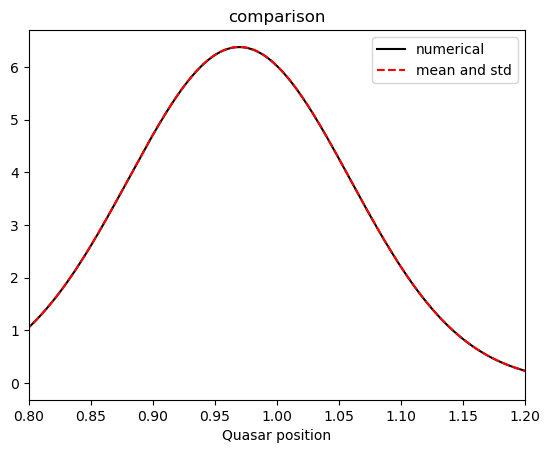

In [19]:
s_norm = 1.43 #scale factor to normalise
plt.plot(x, ML, "k", label="numerical")
plt.plot(x, s_norm*norm(mean, sigma_mean).pdf(x), "--r", label="mean and std")
plt.xlabel("Quasar position")
plt.xlim(mu-sigma, mu+sigma)
plt.title("comparison")
plt.legend()

# heteroscedastic

In [8]:
N = 5 #measurements
mu = 1 #true position
sigma = 0.2
mean_s = 0.2 #mean of sigma_i distribution
sigma_s = 0.05

positions_i = np.random.normal(loc=mu, scale=sigma, size=N)
sigma_i = np.random.normal(loc=mean_s, scale=sigma_s, size=N)

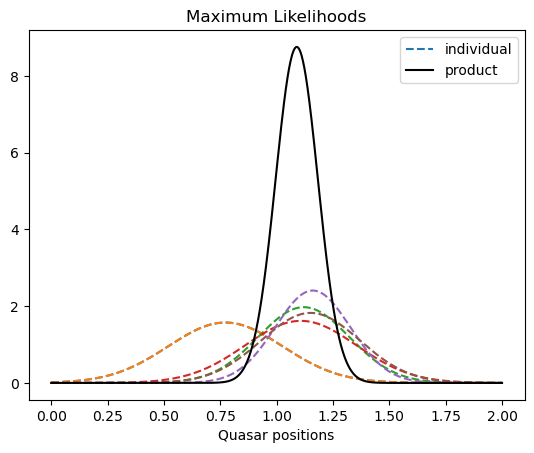

In [9]:
x_s = np.linspace(0, 2, 1000)
ML_s = 1

plt.plot(x_s, norm(positions_i[0], sigma_i[0]).pdf(x), ls="--", label="individual")

#again individual likelihoods
for point, uncert in zip(positions_i, sigma_i):
    MLi = norm(point, uncert).pdf(x)
    plt.plot(x_s, MLi, ls="--")
    ML_s*=MLi

plt.plot(x_s, ML_s, "k", label="product")
plt.xlabel("Quasar positions")
plt.title("Maximum Likelihoods")
plt.legend()

In [10]:
sorted_indices_s = np.argsort(ML_s)
index_max_s = sorted_indices_s[-1]
max_L_mu_s = x_s[index_max_s]

mean_s = np.average(positions_i, weights=1/sigma_i)

print("max L : ", max_L_mu_s)
print("mean  : ", mean_s)

max L :  1.089089089089089
mean  :  1.0761574413714592


In [11]:
der2_s = np.diff(np.log(ML_s), 2) #second derivative
normalised_2nd_s = der2_s/((x_s[1]-x_s[0])**2) #divided by Delta theta ^2
Fisher_matrix_s = -normalised_2nd_s[index_max_s] #evaluated at mu
max_L_sigma_s = Fisher_matrix_s**(-1/2)

sigma_mean_s = np.sum(sigma_i**-2)**(-1/2)

print("max L sigma : ", max_L_sigma_s)
print("sigma mean  : ", sigma_mean_s)

max L sigma :  0.09371316009706863
sigma mean  :  0.09371316009709271


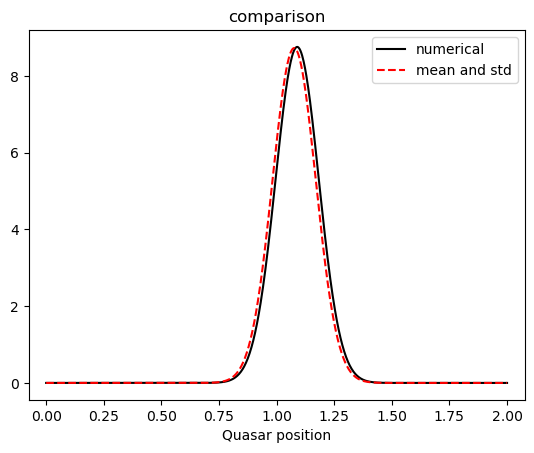

In [23]:
s_norm = 2.05 #scale factor to normalise
plt.plot(x_s, ML_s, "k", label="numerical")
plt.plot(x_s, s_norm*norm(mean_s, sigma_mean_s).pdf(x), "--r", label="mean and std")
plt.xlabel("Quasar position")
plt.xlim(mu-mean_s, mu+mean_s)
plt.title("comparison")
plt.legend()